In [2]:
import torch 
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

BATCH_SIZE = 32
mnist_transforms = transforms.Compose([transforms.ToTensor()])
train_val_dataset = datasets.MNIST(root="./datasets/", train=True, download=True, transform=mnist_transforms)
test_dataset = datasets.MNIST(root="./datasets/", train=False, download=True, transform=mnist_transforms)
train_val_dataset, test_dataset
train_size = int(0.9 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset=train_val_dataset, lengths=[train_size, val_size])
len(train_dataset), len(val_dataset), len(test_dataset)

train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=True)
len(train_dataloader), len(val_dataloader), len(test_dataloader) 

2025-11-18 10:02:32.153412: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-18 10:02:32.507772: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-18 10:02:34.168618: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
100%|██████████| 9.91M/9.91M [00:01<00:00, 6.97MB/s]
100%|██████████| 28.9k/28.9k [00:00<00

(1688, 188, 313)

In [7]:



all_labels = []
all_batches= []
torch.manual_seed(210)
for batch_samples, batch_labels in tqdm(test_dataloader):
    # Ensure samples have the correct shape
    #batch_labels = batch_labels
    #print(batch_samples)
    #batch_samples = batch_samples.requires_grad_() # Enable gradients for attribution
    #baseline_dist = torch.zeros((batch_samples.shape[0],1,28,28)).to(device)
    all_labels.append(batch_labels)
    all_batches.append(batch_samples)

    # Calculate the attributions for each sample in the batch
    #attributions, deltas = ig.attribute(batch_samples, target=batch_labels, return_convergence_delta=True)

    
    # Append attributions and labels for further analysis

    


# Concatenate all attributions and labels
all_labels = torch.cat(all_labels, dim=0)
all_batches = torch.cat(all_batches,dim=0)

100%|██████████| 313/313 [00:00<00:00, 1099.02it/s]


In [24]:
data_X = all_batches[all_labels==9].mean(axis=0)[0,:,:]
data_Y = all_batches[all_labels==3].mean(axis=0)[0,:,:]

In [30]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
thresholds = [0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
avgs = {t: [] for t in thresholds}

for i in range(9):
    for j in range(i,9):
        if i!=j:

            data_X = all_batches[all_labels==i].mean(axis=0)[0,:,:]
            data_Y = all_batches[all_labels==j].mean(axis=0)[0,:,:] 

#plt.imshow(torch.abs(data_X-data_Y).numpy())
            for t in thresholds:
                avgs[t].append((torch.abs(data_X-data_Y).numpy() >t).sum())
            #print((torch.abs(data_X-data_Y).numpy()>0.1).sum())



{0.01: [np.int64(390),
  np.int64(438),
  np.int64(427),
  np.int64(409),
  np.int64(402),
  np.int64(411),
  np.int64(446),
  np.int64(393),
  np.int64(427),
  np.int64(408),
  np.int64(404),
  np.int64(395),
  np.int64(394),
  np.int64(388),
  np.int64(376),
  np.int64(412),
  np.int64(437),
  np.int64(452),
  np.int64(439),
  np.int64(476),
  np.int64(436),
  np.int64(420),
  np.int64(401),
  np.int64(447),
  np.int64(435),
  np.int64(403),
  np.int64(410),
  np.int64(430),
  np.int64(410),
  np.int64(387),
  np.int64(421),
  np.int64(437),
  np.int64(358),
  np.int64(455),
  np.int64(423),
  np.int64(414)],
 0.05: [np.int64(337),
  np.int64(338),
  np.int64(328),
  np.int64(315),
  np.int64(314),
  np.int64(335),
  np.int64(363),
  np.int64(299),
  np.int64(322),
  np.int64(303),
  np.int64(308),
  np.int64(302),
  np.int64(312),
  np.int64(283),
  np.int64(288),
  np.int64(281),
  np.int64(312),
  np.int64(328),
  np.int64(327),
  np.int64(340),
  np.int64(316),
  np.int64(317),
 

In [112]:
import pandas as pd

In [148]:
pd.DataFrame(avgs).mean(axis=0)

0.01    416.972222
0.05    312.305556
0.10    245.083333
0.20    154.722222
0.30     95.277778
0.40     56.166667
0.50     27.666667
0.60      9.722222
0.70      2.111111
0.80      0.500000
0.90      0.083333
dtype: float64

In [137]:
250/784

0.31887755102040816

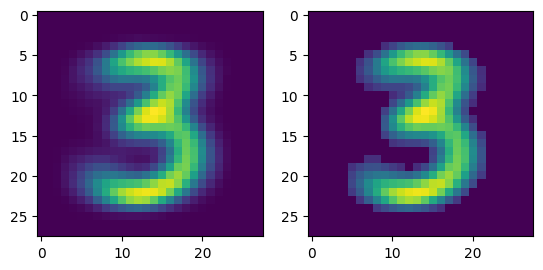

In [146]:
my_image1 = all_batches[all_labels==3].mean(axis=0)[0,:,:]
my_image2 = all_batches[all_labels==3].mean(axis=0)[0,:,:]

fig,ax = plt.subplots(1,2)
#ax[0].imshow(my_image1, vmin=0, vmax=1, cmap='grey', aspect='auto')
#ax[1].imshow(my_image2, vmin=0, vmax=1, cmap='grey', aspect='auto')
#ax[2].imshow(torch.abs(my_image1-my_image2), vmin=0, vmax=1, cmap='grey', aspect='auto')
#ax[2].set_colorbar()

ax[0].imshow(torch.where(my_image1>0.0,my_image1,0))
ax[1].imshow(torch.where(my_image1>0.1,my_image1,0))
#ax[2].imshow(torch.where(my_image1>0.4,my_image1,0))
#ax[3].imshow(torch.where(my_image1>0.6,my_image1,0))

In [87]:
732/3

244.0